### ResNet18 Trainning - Table Classification

**Why ResNet18?**
1. Pretrained on ImageNet → good feature extraction for small datasets
2. Lightweight → trains fast on your GPU
3. Easy to customize → just replace fc layer for your 4 classes
4. Proven performance → widely used for table / object classification

##### Imports

In [12]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

##### Paths & Parameters

In [13]:
BALANCED_DIR = Path("../data/processed/resnet18_dataset_balanced")
MODEL_DIR = Path('../models')

CLASSES = ["need_cleaning", "free", "occupied", "awaiting"]

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]


##### Data Transforms

In [14]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        NORMALIZE_MEAN,
        NORMALIZE_STD
    )
])

##### Load Dataset

In [15]:
dataset = datasets.ImageFolder(BALANCED_DIR, transform=transform)

total_size = len(dataset)

train_size = int(0.7 * total_size)
test_size = total_size - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Dataset ready ✅")


Dataset ready ✅


##### Model Setup (ResNet18)

In [16]:
model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(CLASSES))

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model ready ✅")


c:\Users\anass\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\anass\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready ✅


##### Training Loop

In [17]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss:.4f}")


Epoch 1/50, Loss: 13.7876
Epoch 2/50, Loss: 8.3962
Epoch 3/50, Loss: 7.6141
Epoch 4/50, Loss: 4.2946
Epoch 5/50, Loss: 4.0497
Epoch 6/50, Loss: 3.5741
Epoch 7/50, Loss: 2.4560
Epoch 8/50, Loss: 3.3736
Epoch 9/50, Loss: 3.2607
Epoch 10/50, Loss: 2.5270
Epoch 11/50, Loss: 2.3528
Epoch 12/50, Loss: 2.0310
Epoch 13/50, Loss: 2.3545
Epoch 14/50, Loss: 1.8447
Epoch 15/50, Loss: 1.5768
Epoch 16/50, Loss: 1.5870
Epoch 17/50, Loss: 1.4806
Epoch 18/50, Loss: 1.3638
Epoch 19/50, Loss: 2.0365
Epoch 20/50, Loss: 2.7507
Epoch 21/50, Loss: 2.1994
Epoch 22/50, Loss: 1.5559
Epoch 23/50, Loss: 1.7955
Epoch 24/50, Loss: 1.1241
Epoch 25/50, Loss: 1.1303
Epoch 26/50, Loss: 0.8080
Epoch 27/50, Loss: 1.0696
Epoch 28/50, Loss: 0.9287
Epoch 29/50, Loss: 1.1932
Epoch 30/50, Loss: 0.4991
Epoch 31/50, Loss: 1.2282
Epoch 32/50, Loss: 1.3686
Epoch 33/50, Loss: 1.5109
Epoch 34/50, Loss: 1.3439
Epoch 35/50, Loss: 1.5404
Epoch 36/50, Loss: 1.6359
Epoch 37/50, Loss: 1.7264
Epoch 38/50, Loss: 1.3170
Epoch 39/50, Loss: 1

##### Evaluation

In [23]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}% ✅")

Validation Accuracy: 90.28% ✅


##### Visualize Predictions

Why `unsqueeze(0)`?

Model expects: (batch_size, channels, height, width)

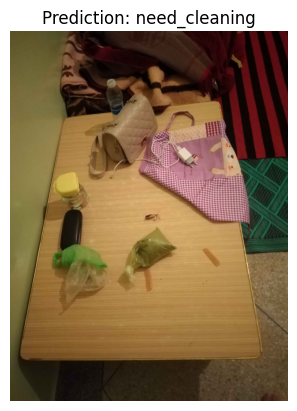

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = r"C:\Users\anass\Desktop\table img test\1.jpg"
image = Image.open(img_path).convert("RGB")


image_tensor = transform(image)             # Apply transforms
image_tensor = image_tensor.unsqueeze(0)    # Add batch dimension
image_tensor = image_tensor.to(DEVICE)

model.eval()

with torch.no_grad():
    outputs = model(image_tensor)
    _, predicted_class = torch.max(outputs, 1)

class_names = dataset.classes   # From ImageFolder


plt.imshow(image)
plt.title(f"Prediction: {class_names[predicted_class.item()]}")
plt.axis("off")
plt.show()

##### Save Model

In [28]:
torch.save(model.state_dict(), MODEL_DIR / "fluxia_classifier.pth")

print("Model saved ✅")


Model saved ✅


##### Save Class Names

In [26]:
torch.save(dataset.classes, MODEL_DIR / "class_names.pth")

##### Save Image Transforms Configuration

In [27]:
import json

config = {
    "img_size": IMG_SIZE,
    "normalize_mean": NORMALIZE_MEAN,
    "normalize_std": NORMALIZE_STD
}

with open("../models/preprocessing.json", "w") as f:
    json.dump(config, f)